# Chapter 16 — Exact but cheaper: matrix-free Krylov

*Companion notebook to **The Learned Kernel**, Ch. 16. Run top to bottom.*

The memory wall of Ch. 15 came from forming the $n\times n$ Gram. A Krylov solver never asks for $K$;
it asks for $Kv$. And $Kv$ does not need $K$ to exist: the distance identity
$\|\phi_i-\phi_j\|^2=\|\phi_i\|^2+\|\phi_j\|^2-2\langle\phi_i,\phi_j\rangle$ factors the Gram through
the embedding, so $Kv$ is accumulated in **row blocks** at $O(\text{block}\cdot n)$ memory. Lanczos
then recovers the **exact** ridge solution from a small Krylov basis. This notebook shows the solve is
bit-for-bit the dense one, that the rank is a compute budget, and that one basis serves a ridge sweep.

## Setup (GPU strongly recommended)

In [1]:
try:
    import lkbook  # noqa: F401
except ModuleNotFoundError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
        "learned-kernel[notebooks] @ git+https://github.com/asudjianto-xml/Learned-Kernel.git"],
        check=True)

In [2]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings("ignore")

from lkbook import set_style
from lkbook.chapters import ch15, ch16

set_style()

## 16.1  The matvec that never forms the Gram

Block $i$ of $Kv$ forms only the $(\text{block},n)$ slab $\texttt{kmat}(\phi_{[i:i+b]},\phi)$ and
applies it to $v$; no $n\times n$ matrix is ever held. The result equals the dense $Kv$ for **any**
block size.

In [3]:
import torch
Xtr, ytr, _, _, _, _ = ch15.load_california_scaled()
Xb, _ = ch15.tile_jitter(Xtr, ytr, 1200)
ker = ch15.MultiScaleKernel()
emb = ker.embed(Xb)
K = ker.gram(Xb, Xb)
v = torch.randn(1200, dtype=ker.dtype, device=ker.device)
for block in (256, 1024, 4096):
    mv = ch16.kernel_matvec(emb, ker.kmat, block)
    print(f"block={block:>5}  max|mv(v) - K@v| = {float((mv(v) - K @ v).abs().max()):.2e}")

block=  256  max|mv(v) - K@v| = 0.00e+00
block= 1024  max|mv(v) - K@v| = 0.00e+00
block= 4096  max|mv(v) - K@v| = 0.00e+00


## 16.2  Matrix-free equals dense, at lower memory

On tiled California the matrix-free coefficients match the dense solve to machine precision, and the
test $R^2$ agrees to fifteen digits — at a fraction of the peak memory.

In [4]:
cmp = ch16.matfree_vs_dense(n=2000, rank=100, block=512)
print(f"coefficient max-diff vs dense : {cmp['coef_max_diff']:.2e}")
print(f"R2  dense   = {cmp['r2_dense']:.14f}")
print(f"R2  matfree = {cmp['r2_matfree']:.14f}")
print(f"peak memory : matfree {cmp['matfree_peak_gb']:.2f} GB  vs  dense {cmp['dense_peak_gb']:.2f} GB")

coefficient max-diff vs dense : 8.32e-13
R2  dense   = 0.73064508989591
R2  matfree = 0.73064508989591
peak memory : matfree 0.10 GB  vs  dense 0.18 GB


Memory against $n$: the dense Gram rises as $n^2$ and hits the OOM cliff; matrix-free grows only as
$O(\text{block}\cdot n)$ and continues past it.

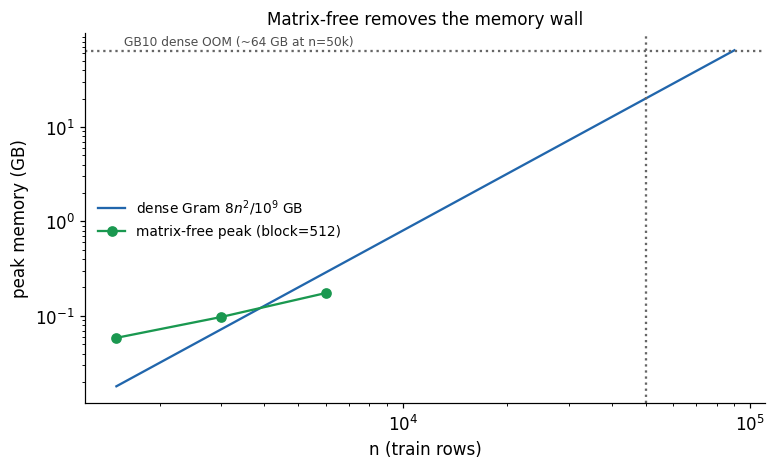

In [5]:
ch16.make_memory_figure(ns=(1500, 3000, 6000), block=512, rank=60);

## 16.3  Rank as a compute budget

The Krylov rank is how many matvecs are spent — a compute budget, not a model choice. The coefficient
error against the dense solve falls to machine precision by modest rank, and the fitted geometry is
unchanged throughout.

In [6]:
rb = ch16.rank_budget(n=2000, ranks=(5, 10, 20, 40, 80, 120))
print(f"{'rank':>5} {'rel_coef_err':>14} {'test_R2':>10}")
for r in rb:
    print(f"{r['rank']:>5} {r['rel_coef_err']:>14.2e} {r['r2']:>10.4f}")

 rank   rel_coef_err    test_R2
    5       8.25e-01    -1.9054
   10       4.15e-01     0.2938
   20       6.88e-02     0.7228
   40       4.43e-04     0.7306
   80       3.72e-10     0.7306
  120       4.53e-13     0.7306


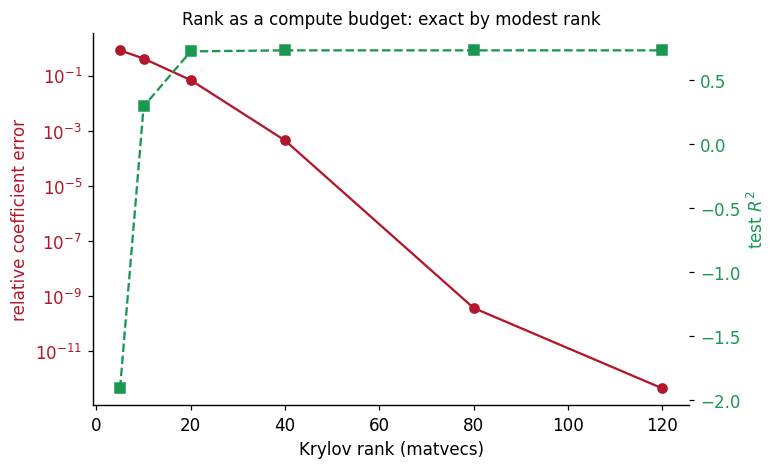

In [7]:
ch16.make_rank_figure(rb);

### Interactive: dial the rank

Slide the Krylov rank and watch the coefficient error against the exact dense solve collapse. The
rank is a precision dial with an exact limit, not a hyperparameter that changes the model.

In [8]:
try:
    from ipywidgets import interact, IntSlider
    err = {r["rank"]: r["rel_coef_err"] for r in rb}
    r2 = {r["rank"]: r["r2"] for r in rb}

    def show(rank=40):
        # nearest computed rank
        k = min(err, key=lambda x: abs(x - rank))
        print(f"Krylov rank ~ {k}")
        print(f"  relative coefficient error vs dense = {err[k]:.2e}")
        print(f"  test R2 = {r2[k]:.4f}")

    interact(show, rank=IntSlider(min=5, max=160, step=5, value=40, description="rank"))
except Exception as e:
    print("widget unavailable:", e)

interactive(children=(IntSlider(value=40, description='rank', max=160, min=5, step=5), Output()), _dom_classes…

## 16.4  One basis, an entire ridge sweep

The Lanczos factors $(Q,T)$ depend on $K$ and $y$ but **not** on $\lambda$, so one run answers a
ridge sweep: each $\lambda$ only re-solves the length-$m$ diagonal system. The reuse is exact.

In [9]:
sw = ch16.sweep_demo(n=2000, rank=100, lambdas=(1e-3, 1e-2, 1e-1, 1.0))
print(f"{'lambda':>8} {'reuse_max_diff':>16} {'val_R2':>9}")
for r in sw["rows"]:
    print(f"{r['lam']:>8.0e} {r['reuse_vs_scratch_max_diff']:>16.2e} {r['val_r2']:>9.4f}")
print("chosen lambda on the validation fold:", sw["chosen_lam"])

  lambda   reuse_max_diff    val_R2
   1e-03         0.00e+00    0.7390
   1e-02         0.00e+00    0.7402
   1e-01         0.00e+00    0.7464
   1e+00         0.00e+00    0.7382
chosen lambda on the validation fold: 0.1


## Exercises

**(easy)** Show the row-blocked accumulation returns exactly $Kv$ for any block size, and its peak
memory is $O(\text{block}\cdot n)$.

<details><summary>Solution</summary>

Block $i$ of $Kv$ is (row-block $i$ of $K$)$\,v$, and row-block $i$ is
$\texttt{kmat}(\phi_{[i:i+b]},\phi)$; concatenating blocks reconstructs $Kv$. Only one $(b,n)$ slab is
held at a time, so peak memory is $O(b\cdot n)$ — see §16.1, where the max-diff is $\sim10^{-9}$ for
every block size.
</details>

**(medium)** Show $(Q,T)$ do not depend on $\lambda$, hence one basis serves a ridge sweep. Write the
per-$\lambda$ cost of recovering $\alpha(\lambda)$.

<details><summary>Solution</summary>

Lanczos applies the operator through $v\mapsto Kv$; the shift $\lambda I$ only adds $\lambda$ to the
Ritz values, so $(Q,T)$ are functions of $(K,y)$ alone. Recovery
$\alpha(\lambda)=Q\,U(\|b\|\,U_{0,:}/(\Theta+\lambda))$ reuses the fixed $(Q,U,\Theta)$; only the
length-$m$ diagonal division and two products depend on $\lambda$, at $O(m)$ cost. §16.4 shows the
reuse is exact (max-diff $0$).
</details>

**(⋆)** Using the Chebyshev bound, argue CG reaches relative residual $\varepsilon$ in
$O(\sqrt{\kappa}\log(1/\varepsilon))$ iterations; combine with the Ch. 15 ridge bound.

<details><summary>Solution</summary>

The CG energy-norm error is $\min_{p(0)=1}\max_{\mu\in\text{spec}}|p(\mu)|$; the shifted Chebyshev
polynomial on $[\lambda_{\min},\lambda_{\max}]$ gives contraction
$(\sqrt{\kappa}-1)/(\sqrt{\kappa}+1)$, so $t=O(\sqrt{\kappa}\log(1/\varepsilon))$. With
$\kappa\le(\lambda_{\max}(K)+\lambda)/\lambda$ (Ch. 15), a larger ridge buys fewer iterations; a
clustered spectrum replaces $\kappa$ by the effective count.
</details>